### Trasformacion (a,M) -> (x,y)

\begin{equation}
    \mathbb{J}_{X \varepsilon } \equiv \frac{\partial \widetilde{X}}{\partial \widetilde{\varepsilon}} \equiv 
    \begin{pmatrix} 
    \partial_ax & \partial_Mx\\
    \partial_ay & \partial_My 
    \end{pmatrix}
\end{equation}

$$
\partial_ax = (\cos(E) - e) A + \sqrt{1-e^2}\sin(E) B
$$

$$
\partial_ay = (\cos(E) - e) C + \sqrt{1-e^2}\sin(E) D
$$

$$
\partial_Mx = -\frac{a}{r} \sin(E) A + \frac{a}{r} \sqrt{1-e^2} \cos(E) B
$$

$$
\partial_My = -\frac{a}{r} \sin(E) C + \frac{a}{r} \sqrt{1-e^2} \cos(E) D
$$

In [5]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [6]:
def coplanar_jacobian_XoE(a: np.ndarray, E: np.ndarray, constants: list) -> np.array:
    e = 0
    
    #constants
    A = constants[0]
    B = constants[1]
    C = constants[2]
    D = constants[3]

    a_r = a * (1 - e * np.cos(E))

    partial_aX = (np.cos(E) - e) * A - (1-e**2)**0.5 * np.sin(E) * B
    partial_aY = (np.cos(E) - e) * C - (1-e**2)**0.5 * np.sin(E) * D
    partial_MX = -a_r * np.sin(E) * A - a_r * (1-e**2)**0.5 * np.cos(E) * B
    partial_MY = -a_r * np.sin(E) * C - a_r * (1-e**2)**0.5 * np.cos(E) * D

    return np.array([[partial_aX, partial_MX], [partial_aY, partial_MY]])

In [7]:
def trasfromation_vectorized(a: np.ndarray, E: np.ndarray, constants: list) -> np.ndarray:

    A, B, C, D = constants
    e = 0
    cosE = np.cos(E)
    sinE = np.sin(E)
    sqrt1me2 = np.sqrt(1 - e**2)  # = 1 for e=0

    x = a * (cosE - e) * A - a * sqrt1me2 * sinE * B
    y = a * (cosE - e) * C - a * sqrt1me2 * sinE * D

    return np.column_stack((x, y))

def inverse_transformation_vectorized(x: np.ndarray, y: np.ndarray, constants: list) -> tuple:
    """
    Calcula los valores de a y E a partir de x, y usando los mismos parámetros que trasfromation_vectorized.
    Asume e=0 (caso coplanar circular).
    Devuelve a y E como arrays.
    """
    A, B, C, D = constants
    e = 0  # Asumido por el contexto

    # Para e=0, las ecuaciones son:
    # x = a * (cosE * A - sinE * B)
    # y = a * (cosE * C - sinE * D)
    # Esto es un sistema lineal en cosE y sinE:
    # [x]   [A  -B] [a*cosE]
    # [y] = [C  -D] [a*sinE]
    # Lo resolvemos para cada par (x, y):

    # Matriz de coeficientes
    M = np.array([[A, -B],
                  [C, -D]])

    # Inversa de la matriz de coeficientes
    Minv = np.linalg.inv(M)

    # x, y deben ser arrays de igual shape
    xy = np.stack([x, y], axis=-1)  # (..., 2)

    # Aplicar la inversa a cada par (x, y)
    # resultado: (..., 2) donde [:,0]=a*cosE, [:,1]=a*sinE
    a_cosE, a_sinE = np.dot(xy, Minv.T)[...,0], np.dot(xy, Minv.T)[...,1]

    # Calcular a y E
    a = np.sqrt(a_cosE**2 + a_sinE**2)
    E = np.arctan2(a_sinE, a_cosE)

    return a, E


In [8]:
def P_xy(x, y, P_aE_func, coplanar_jacobian_XoE, a_func, E_func):
    """
    Calcula P(x, y) = P_aE(a(x, y), E(x, y)) * |det J|, donde J es el inverso del jacobiano calculado en coplanar_jacobian_XoE.

    Args:
        x (float): coordenada x
        y (float): coordenada y
        P_aE_func (callable): función que recibe (a, E) y devuelve P_aE
        coplanar_jacobian_XoE (callable): función que recibe (x, y) y devuelve el jacobiano de (a, E) respecto de (x, y)
        a_func (callable): función que recibe (x, y) y devuelve a
        E_func (callable): función que recibe (x, y) y devuelve E

    Returns:
        float: P(x, y)
    """
    a = a_func(x, y)
    E = E_func(x, y)
    J = coplanar_jacobian_XoE(x, y)  # J = d(a,E)/d(x,y)
    # El jacobiano de (x,y) respecto de (a,E) es el inverso de J
    det_J = np.linalg.det(J)
    if det_J == 0:
        return 0.0
    det_Jinv = 1.0 / det_J
    P_aE = P_aE_func(a, E)
    return P_aE * abs(det_Jinv)

### Conteo de objetos dentro de caja

In [9]:
N = int(1e7)

#coplanar elements
w = 0
Omega = 0 
i = 0
e = 0

A = np.cos(w) * np.cos(Omega) - np.cos(i) * np.sin(Omega) * np.sin(w)
B = np.sin(w) * np.cos(Omega) + np.cos(i) * np.sin(Omega) * np.cos(w)
C = np.sin(Omega) * np.cos(w) + np.cos(i) * np.cos(Omega) * np.sin(w)
D = np.sin(Omega) * np.sin(w) - np.cos(i) * np.cos(Omega) * np.cos(w)
constants = [A, B, C, D]

a = np.random.uniform(0, 2, N)
E = np.random.uniform(0, 2*np.pi, N)

aE = np.column_stack([a, E])

In [10]:
xy = trasfromation_vectorized(a, E, constants)
xy

array([[ 0.35837368,  0.2469087 ],
       [ 0.16173592, -0.40012301],
       [ 1.24318312,  0.87660825],
       ...,
       [-0.18951627, -0.06538613],
       [-0.32059651, -0.13531209],
       [-0.17659744, -1.76575544]])

In [11]:
x_uniform = xy[:,0]
y_uniform = xy[:,1]

cx = 0.5
cy = 0.5

dx = 0.01
dy = 0.01

#masking para obtener los objetos dentro de la caja
objsx = (abs(x_uniform - cx) <= dx) 
objsy = (abs(y_uniform - cy) <= dy) 

objects = objsx * objsy 

print(f'Number of objects inside volume: {objects.sum()}')

idx = 0
xy_in_box = xy[objects][idx]
aE_in_box = aE[objects][idx]
print('x y seleccionado para calcular el Jacobiano: ', xy_in_box)
print('a E seleccionado para calcular el Jacobiano: ', aE_in_box)

Number of objects inside volume: 464
x y seleccionado para calcular el Jacobiano:  [0.49388344 0.49892323]
a E seleccionado para calcular el Jacobiano:  [0.70202937 0.79047443]


### Calculo teorico

In [12]:
JXoE = coplanar_jacobian_XoE(aE_in_box[0], aE_in_box[1], constants)
JEoX = np.linalg.inv(JXoE)
det = np.linalg.det(JEoX)
det

1.4244418238092615

In [13]:
a_max = 2
a_min = 0
E_max = 2*np.pi
E_min = 0

P_aE = 1/(a_max - a_min) * 1/(E_max - E_min)
P_aE

0.07957747154594767

In [14]:
Delta = (2*dx) * (2*dy)
Delta 

0.0004

In [15]:
def P_aE_func(a, E):
    return 1/(a_max - a_min) * 1/(E_max - E_min)

def P_xy(x, y, P_aE_func, coplanar_jacobian_XoE, constants):
    """
    Calcula P(x, y) = P_aE(a(x, y), E(x, y)) * |det J|, donde J es el inverso del jacobiano calculado en coplanar_jacobian_XoE.

    Args:
        x (float): coordenada x
        y (float): coordenada y
        P_aE_func (callable): función que recibe (a, E) y devuelve P_aE
        coplanar_jacobian_XoE (callable): función que recibe (x, y) y devuelve el jacobiano de (a, E) respecto de (x, y)
        a_func (callable): función que recibe (x, y) y devuelve a
        E_func (callable): función que recibe (x, y) y devuelve E

    Returns:
        float: P(x, y)
    """
    a, E = inverse_transformation_vectorized(x, y, constants)
    J = coplanar_jacobian_XoE(a, E, constants)  # J = d(a,E)/d(x,y)
    # El jacobiano de (x,y) respecto de (a,E) es el inverso de J
    det_J = np.linalg.det(J)
    if det_J == 0:
        return 0.0
    det_Jinv = 1.0 / det_J

    P_aE = P_aE_func(0, 0)

    return P_aE * abs(det_Jinv)

In [16]:
P_xy(xy_in_box[0], xy_in_box[1], P_aE_func, coplanar_jacobian_XoE, constants) * Delta * N

453.4139148121572

In [17]:
num = N * P_aE * det * Delta
print('numero de objetos teorico: ', num)

numero de objetos teorico:  453.41391481215726


In [18]:
det

1.4244418238092615

In [19]:
#variando el tamaño de la caja 

N = int(1e7)

cx = 0.5
cy = 0.5
drs = np.linspace(0.01, 0.5, 10)

idx = 0

n_size = []
N_size = []
for dr in tqdm(drs):
    dx = dr; dy = dr

    objsx = (abs(x_uniform - cx) <= dx) 
    objsy = (abs(y_uniform - cy) <= dy) 

    objects = objsx * objsy 
    n_size.append(objects.sum())

    xy_in_box = xy[objects][idx]
    aE_in_box = aE[objects][idx]
    
    JEoX = np.linalg.inv(coplanar_jacobian_XoE(aE_in_box[0], aE_in_box[1], constants))
    det = np.linalg.det(JEoX)

    Delta = (2*dx) * (2*dy)
    num = N * P_aE * det * Delta
    
    N_size.append(num)


#variando el centro de la caja

centers = np.linspace(0.1, 0.8, 10)

dx = 0.01
dy = 0.01
Delta = (2*dx) * (2*dy)

idx = 0

n_center = []
N_center = []
for c in tqdm(centers):
    cx = c; cy= c

    objsx = (abs(x_uniform - cx) <= dx) 
    objsy = (abs(y_uniform - cy) <= dy) 

    objects = objsx * objsy 
    n_center.append(objects.sum())

    xy_in_box = xy[objects][idx]
    aE_in_box = aE[objects][idx]
    
    JEoX = np.linalg.inv(coplanar_jacobian_XoE(aE_in_box[0], aE_in_box[1], constants))
    det = np.linalg.det(JEoX)
    num = N * P_aE * det * Delta
    
    N_center.append(num)


#variando el numero de objetos
N_points = np.linspace(1e4, 1e8, 10)

cx = 0.5
cy = 0.5

dx = 0.01
dy = 0.01
Delta = (2*dx) * (2*dy)

n_objs = []
N_objs = []
for n in tqdm(N_points):
    N = int(n)

    a = np.random.uniform(0, 2, N)
    E = np.random.uniform(0, 2*np.pi, N)
    aE = np.column_stack([a, E])
    xy = trasfromation_vectorized(a, E, constants)

    x_uniform = xy[:,0]
    y_uniform = xy[:,1]

    objsx = (abs(x_uniform - cx) <= dx) 
    objsy = (abs(y_uniform - cy) <= dy) 

    objects = objsx * objsy 
    
    n_objs.append(objects.sum())

    xy_in_box = xy[objects][idx]
    aE_in_box = aE[objects][idx]
    
    JEoX = np.linalg.inv(coplanar_jacobian_XoE(aE_in_box[0], aE_in_box[1], constants))
    det = np.linalg.det(JEoX)

    num = N * P_aE * det * Delta
    
    N_objs.append(num)    

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [01:04<00:00,  6.46s/it]


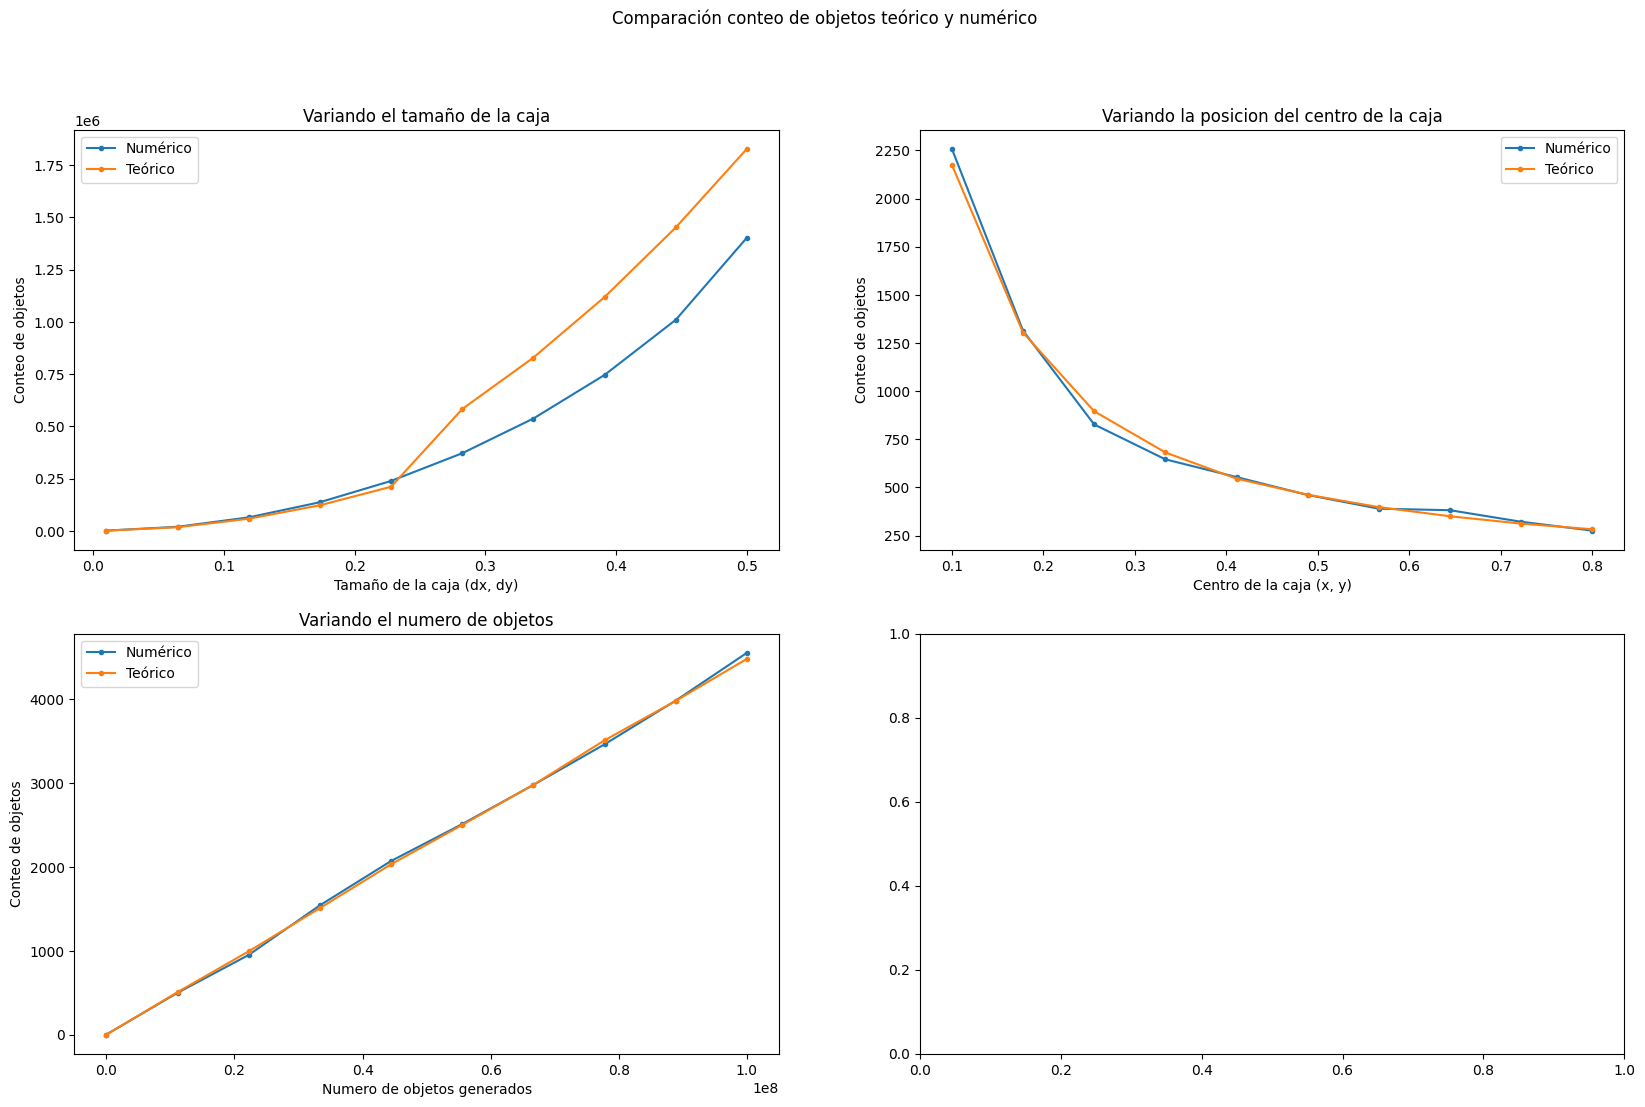

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(20,12))
axs[0, 0].plot(drs, n_size, '.-', label='Numérico')
axs[0, 0].plot(drs, N_size, '.-', label='Teórico')
axs[0, 0].set_title('Variando el tamaño de la caja')
axs[0, 0].set_xlabel('Tamaño de la caja (dx, dy)')
axs[0, 0].set_ylabel('Conteo de objetos')
axs[0, 0].legend()

axs[0, 1].plot(centers, n_center, '.-', label='Numérico')
axs[0, 1].plot(centers, N_center, '.-', label='Teórico')
axs[0, 1].set_xlabel('Centro de la caja (x, y)')
axs[0, 1].set_ylabel('Conteo de objetos')
axs[0, 1].set_title('Variando la posicion del centro de la caja')
axs[0, 1].legend()      

axs[1, 0].plot(N_points, n_objs, '.-', label='Numérico')
axs[1, 0].plot(N_points, N_objs, '.-', label='Teórico')
axs[1, 0].set_xlabel('Numero de objetos generados')
axs[1, 0].set_ylabel('Conteo de objetos')
axs[1, 0].set_title('Variando el numero de objetos')
axs[1, 0].legend()

"""
axs[1, 1].plot(total_objects, objs, 'tab:red', label='Te')
axs[1, 1].axhline(obj_in_box, label='Teórico')
axs[1, 1].set_xlabel('Numero de vector de objetos')
axs[1, 1].set_ylabel('Conteo de objetos')
axs[1, 1].set_title('Variando el vector de objetos')
axs[1, 1].legend()
"""
plt.suptitle("Comparación conteo de objetos teórico y numérico")
plt.show();

In [21]:
# Contar cuántos puntos de xy están dentro de una circunferencia de radio 0.2 centrada en (1, 0)
centro = np.array([1, 0])
radio = 0.2
distancias = np.linalg.norm(xy - centro, axis=1)
num_puntos_en_circulo = np.sum(distancias <= radio)
print(f"Número de puntos dentro de la circunferencia: {num_puntos_en_circulo}")


Número de puntos dentro de la circunferencia: 1004278


In [22]:
def P_xy_vectorized(x, y):
    """
    Rutina vectorizada que recibe solo x e y (pueden ser arrays) y retorna P_xy(x, y).
    """
    # Asume que P_aE_func, coplanar_jacobian_XoE, constants están definidos en el entorno global
    # x, y pueden ser arrays de igual shape
    x = np.asarray(x)
    y = np.asarray(y)
    # Si x e y son escalares, simplemente llama la función original
    if x.shape == () and y.shape == ():
        return P_xy(x, y, P_aE_func, coplanar_jacobian_XoE, constants)
    # Si no, vectoriza usando np.vectorize
    vectorized_func = np.vectorize(lambda xi, yi: P_xy(xi, yi, P_aE_func, coplanar_jacobian_XoE, constants))
    return vectorized_func(x, y)



In [23]:
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])
P_xy_vectorized(x, y)

array([0.01930037, 0.01477717, 0.01186271])

In [24]:
def integral_Pxy_dentro_circulo(P_xy, a, b, r, n_r=50, n_theta=100):
    """
    Calcula la integral de superficie de P_xy dentro de un círculo de radio r y centro (a, b)
    usando cuadratura gaussiana en coordenadas polares.

    P_xy: función de dos variables, P_xy(x, y)
    a, b: centro del círculo
    r: radio del círculo
    n_r: número de puntos de cuadratura en radio (por defecto 50)
    n_theta: número de puntos de cuadratura en ángulo (por defecto 100)
    """
    # Cuadratura gaussiana en r de 0 a r
    rs, ws_r = np.polynomial.legendre.leggauss(n_r)
    # Transformar de [-1,1] a [0, r]
    rs = 0.5 * (rs + 1) * r
    ws_r = ws_r * 0.5 * r  # dr = r/2

    # Cuadratura gaussiana en theta de 0 a 2pi
    thetas, ws_theta = np.polynomial.legendre.leggauss(n_theta)
    thetas = 0.5 * (thetas + 1) * 2 * np.pi
    ws_theta = ws_theta * np.pi  # dtheta = pi

    # Crear mallas para r y theta
    rs_mesh, thetas_mesh = np.meshgrid(rs, thetas, indexing='ij')
    ws_r_mesh, ws_theta_mesh = np.meshgrid(ws_r, ws_theta, indexing='ij')

    # Coordenadas cartesianas
    xs = a + rs_mesh * np.cos(thetas_mesh)
    ys = b + rs_mesh * np.sin(thetas_mesh)

    # Evaluar la función en la malla
    integrando = P_xy_vectorized(xs, ys) * rs_mesh

    # Sumar todos los puntos ponderados
    integral = np.sum(integrando * ws_r_mesh * ws_theta_mesh)
    return integral

# Ejemplo de uso:
# def P_xy(x, y):
#     return np.exp(-(x**2 + y**2))
# resultado = integral_Pxy_dentro_circulo(P_xy, 1, 0, 0.2)
# print("Integral de superficie dentro del círculo:", resultado)


In [25]:
# Contar cuántos puntos de xy están dentro de una circunferencia de radio 0.2 centrada en (1, 0)
centro = np.array([1, 0])
radio = 0.8
distancias = np.linalg.norm(xy - centro, axis=1)
num_puntos_en_circulo = np.sum(distancias <= radio)
print(f"Número de puntos dentro de la circunferencia numerico: {num_puntos_en_circulo}")

a = centro[0]
b = centro[1]
r = radio
num_teorico = integral_Pxy_dentro_circulo(P_xy, a, b, r, n_r=50, n_theta=100) * N
print(f"Número de puntos dentro de la circunferencia teórico: {num_teorico}")

Número de puntos dentro de la circunferencia numerico: 17762454
Número de puntos dentro de la circunferencia teórico: 17762994.84122759


In [26]:
#a, e, M next step

#a, e, M, w - x,y vx, vy

#integrar x y en una esfera pero vx vy en un intervalo vx -1, 1, vy -1, 1 y que el vector x, y, vx, vy este dentro de esos intervalos elegirlos entre ese intervalo

In [27]:
#prueba 1: integrar la probabilidad en un hipercubo x, y, vx, vy 
#prueba 2: integrar la probabilidad en una circulo en x, y, pero cubo en velocidad vx, vy 
#prueba 3: integrar en circulo en x, y, pero en velocidad todas de menos infinito a mas infinito